## Summarized Findings

Wine grading and pricing is a lot more subjective than what consumers may believe. Although these signals are often treated as indicators of quality, both prices and ratings are influenced by subjective and contextual factors rather than purely objective measures of quality.

Our findings show that consumers should not rely solely on price or score when choosing wines and retailers can benefit by highlighting regional identity and favored flavor profiles in marketing and stock selection.

To get the dataset visit https://www.kaggle.com/datasets/zynicide/wine-reviews and download the winemag-data-130k-v2.csv. Then upload it in the /content/ folder

##VIDEO LINK
https://youtu.be/e73e7ImTaCM

### Data loaded and put in Tidy form

In [ ]:
dataset_path = "/content/winemag-data-130k-v2.csv"

In [ ]:
import polars as pl
import re
from sklearn.feature_extraction.text import CountVectorizer
import shutil
import matplotlib.pyplot as plt

pl.Config.set_tbl_width_chars(shutil.get_terminal_size().columns)

polars.config.Config

In [ ]:
df = (
    pl.read_csv(dataset_path)
    .with_columns([
        pl.col("description").cast(pl.Utf8).str.to_lowercase().alias("clean_desc"),
        pl.col("region_1").cast(pl.Utf8).str.strip_chars().replace("", None),
        pl.col("region_2").cast(pl.Utf8).str.strip_chars().replace("", None),
    ])
    .with_columns(
        pl.coalesce([pl.col("region_1"), pl.col("region_2")]).alias("region")
    )
    .drop(["region_1", "region_2", "designation"])
    .drop_nulls(["clean_desc", "region", "country", "taster_name", "points"])
)

### Key findings

In [ ]:
# @title create dataframes used to produce visualizations of key findings (explained in more detail in Substantiation)
#flavor Tags
flavor_tags = [
    "black cherry",
    "fruit flavors",
    "palate offers",
    "ready drink",
    "medium bodied",
    "black fruit",
    "black pepper",
    "red berry",
    "black currant",
    "red fruit"
]

tag_exprs = [
    pl.when(pl.col("clean_desc").str.contains(rf"\b{re.escape(tag)}\b"))
      .then(pl.lit(tag))
      .otherwise(None)
      .alias(tag)
    for tag in flavor_tags
]

df = (
    df.with_columns(tag_exprs)
      .with_columns(
          pl.concat_list(flavor_tags)
            .list.drop_nulls()
            .alias("matched_flavor_tags")
      )
      .drop(flavor_tags)
)

df_clean = df.filter(
    (pl.col("matched_flavor_tags").list.len() > 0)
)
#bias adjustment
global_mean = df_clean.select(pl.col("points").mean()).item()

taster_bias = (
    df_clean
    .group_by("taster_name")
    .agg(
        pl.col("points").mean().alias("taster_mean")
    )
    .with_columns(
        (pl.col("taster_mean") - global_mean).alias("bias")
    )
)

df_adjusted = (
    df_clean
    .join(taster_bias, on="taster_name", how="left")
    .with_columns(
        (pl.col("points") - pl.col("bias")).alias("adjusted_points")
    )
)

#Explode Flavors
df_flavors = df_adjusted.explode("matched_flavor_tags")

#Aggregate region + Flavor Data
region_flavor = (
    df_flavors
    .group_by(["region", "matched_flavor_tags"])
    .agg([
        pl.len().alias("review_count"),
        pl.col("adjusted_points").mean().round(2).alias("avg_adjusted_points"),
        pl.col("price").mean().round(2).alias("avg_price")
    ])
    .filter(pl.col("review_count") >= 5)
)


# Top Flavors Per Region

top_flavors_per_region = (
    region_flavor
    .sort(
        by=["region", "review_count", "avg_adjusted_points"],
        descending=[False, True, True]
    )
    .with_columns(
        pl.col("review_count")
        .rank("dense", descending=True)
        .over("region")
        .alias("rank_in_region")
    )
    .filter(pl.col("rank_in_region") <= 1)
    .sort(
        ["region", "rank_in_region", "review_count", "avg_adjusted_points"],
        descending=[False, False, True, True]
    )
)


#Buidling Region Summary --> needed for KeyFindings

region_review_counts = (
    df
    .group_by(["region", "country"])
    .agg(pl.len().alias("total_reviews"))
)

favorite_flavor = (
    top_flavors_per_region
    .select([
        "region",
        pl.col("matched_flavor_tags").alias("favorite_flavor"),
        pl.col("avg_adjusted_points").alias("favorite_flavor_score")
    ])
)

region_summary = (
    region_review_counts
    .join(favorite_flavor, on="region", how="left")
    .sort("total_reviews", descending=True)
)

#Reviwer bias table
top_tasters = (
    taster_bias
    .filter(pl.col("taster_name").is_not_null())
    .sort("bias", descending=True)
    .head(15)
)

#average wine score per flavor
avg_score_per_flavor = (
    df_flavors
    .group_by("matched_flavor_tags")
    .agg([
        pl.len().alias("num_wines"),
        pl.col("adjusted_points").mean().round(2).alias("avg_adjusted_score"),
        pl.col("points").mean().round(2).alias("avg_raw_score"),
        pl.col("price").mean().round(2).alias("avg_price")
    ])
    .sort("avg_adjusted_score", descending=True)
)


top_phrases = [
    "black cherry", "fruit flavors", "palate offers", "ready drink",
    "medium bodied", "black fruit", "black pepper",
    "red berry", "black currant", "red fruit"
]
# Build case-insensitive regex from selected phrases
pattern = "(?i)(" + "|".join(map(re.escape, top_phrases)) + ")"

# Tag + explode
df_exp = (
    df_q1.with_columns(
        pl.col("clean_desc").str.extract_all(pattern).alias("flavor_tags")
    )
    .explode("flavor_tags")
    .drop_nulls("flavor_tags")
    .with_columns(pl.col("flavor_tags").str.to_lowercase())
)

result = (
        df_exp
        .group_by("flavor_tags")
        .agg([
            pl.len().alias("num_wines"),
            pl.col("points").mean().alias("avg_points"),
            pl.col("points").std().alias("std_points"),
            pl.col("price").mean().alias("avg_price"),
        ])
        .sort("avg_points", descending=True)
    )


First, flavor language in reviews is strongly associated with scoring/pricing patterns. Wines described with darker fruit and spice characteristics (such as black cherry, black currant, and black pepper) receive higher average scores than wines described using broader or more generic terms. This suggests that certain stylistic flavor profiles are consistently favored by reviewers.


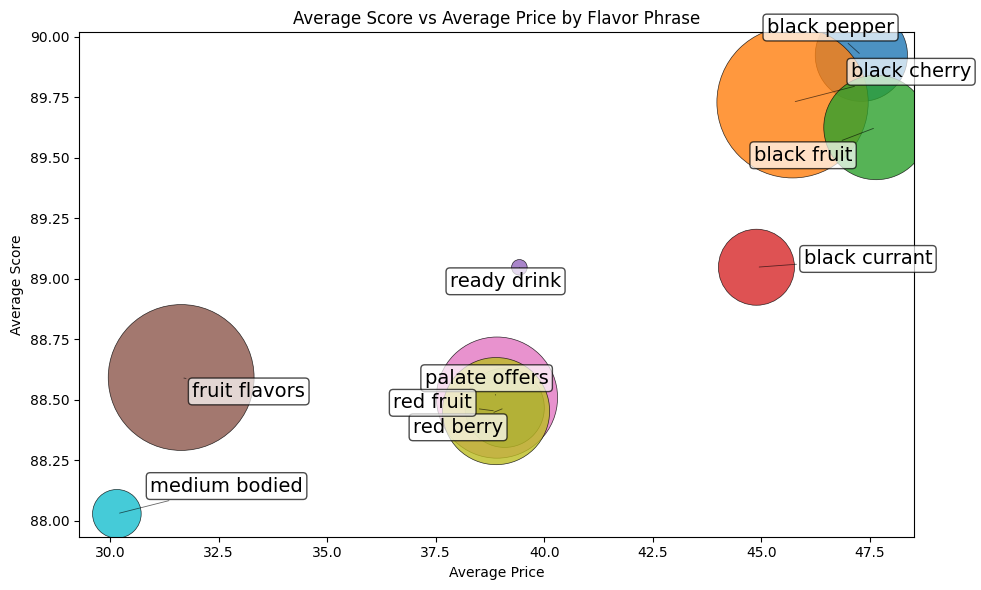

In [ ]:
# @title
# Scatter plot of average score vs average price by flavor phrase
plot_df = result.sort("avg_points", descending=True)

x = plot_df.get_column("avg_price").to_list()
y = plot_df.get_column("avg_points").to_list()
sizes = [n * 3 for n in plot_df.get_column("num_wines").to_list()]
labels = plot_df.get_column("flavor_tags").to_list()

# Assign a different color to each point
colors = plt.cm.tab10(range(len(labels)))

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=sizes, c=colors, alpha=0.8, edgecolors="black", linewidths=0.5)

# Custom offset for each flavor label
custom_offsets = {
    "black cherry": (42, 18),
    "fruit flavors": (8, -14),
    "palate offers": (-52, 10),
    "ready drink": (-50, -14),
    "medium bodied": (24, 16),
    "black fruit": (-88, -24),
    "black pepper": (-68, 16),
    "red berry": (-66, -18),
    "black currant": (34, 2),
    "red fruit": (-74, 2),
}

for i, label in enumerate(labels):
    dx, dy = custom_offsets.get(label, (10, 10))
    plt.annotate(
        label,
        (x[i], y[i]),
        fontsize=14,
        xytext=(dx, dy),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6)
    )

plt.xlabel("Average Price")
plt.ylabel("Average Score")
plt.title("Average Score vs Average Price by Flavor Phrase")
plt.tight_layout()
plt.show()

Second, our findings show that the most famous wine producing countries, like the US, France, and Spain, do not necessarily have the highest rated wines. Instead, countries with smaller or less globally renowned wine industries, such as Canada and Australia, achieve higher average scores, highlighting that reputation does not always align with quality.


In [ ]:
# @title
import plotly.express as px

# Clean country names for mapping
df_clean = (
    df
    .drop_nulls(["country"])
    .with_columns(
        pl.when(pl.col("country") == "US").then(pl.lit("United States"))
        .when(pl.col("country") == "England").then(pl.lit("United Kingdom"))
        .otherwise(pl.col("country"))
        .alias("country")
    )
)

# Total number of reviews
total_reviews = df_clean.height

# Count reviews per country
country_counts = (
    df_clean
    .group_by("country")
    .agg(pl.len().alias("review_count"))
)

# Calculate percentage share
country_percentage = (
    country_counts
    .with_columns(
        ((pl.col("review_count") / total_reviews) * 100)
        .round(2)
        .alias("percent_reviews")
    )
    .sort("percent_reviews", descending=True)
)

country_percentage_pd = country_percentage.to_pandas()

fig = px.choropleth(
    country_percentage_pd,
    locations="country",
    locationmode="country names",
    color="percent_reviews",
    hover_name="country",
    color_continuous_scale="Plasma",
    title="Percentage of Wine Reviews by Country"

)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

In [ ]:
# @title
import plotly.express as px

# Top 10 countries by average wine rating
avg_rating_map_df = (
    df
    .drop_nulls(["country", "points"])
    .with_columns(
        pl.when(pl.col("country") == "US").then(pl.lit("United States"))
        .when(pl.col("country") == "England").then(pl.lit("United Kingdom"))
        .otherwise(pl.col("country"))
        .alias("country")
    )
    .group_by("country")
    .agg([
        pl.col("points").mean().round(2).alias("avg_rating"),
        pl.len().alias("review_count")
    ])
    .sort("avg_rating", descending=True)
    .head(10)
)

avg_rating_map_pd = avg_rating_map_df.to_pandas()

fig = px.choropleth(
    avg_rating_map_pd,
    locations="country",
    locationmode="country names",
    color="avg_rating",
    hover_name="country",
    hover_data={"avg_rating": True, "review_count": True},
    color_continuous_scale="Plasma",
    title="Top Countries by Average Wine Rating"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar_title="Avg rating"
)

fig.show()

Third, we observed measurable reviewer bias. Even after accounting for the average score of each wine, some tasters consistently rate wines higher or lower than the baseline, demonstrating systematic differences in scoring.

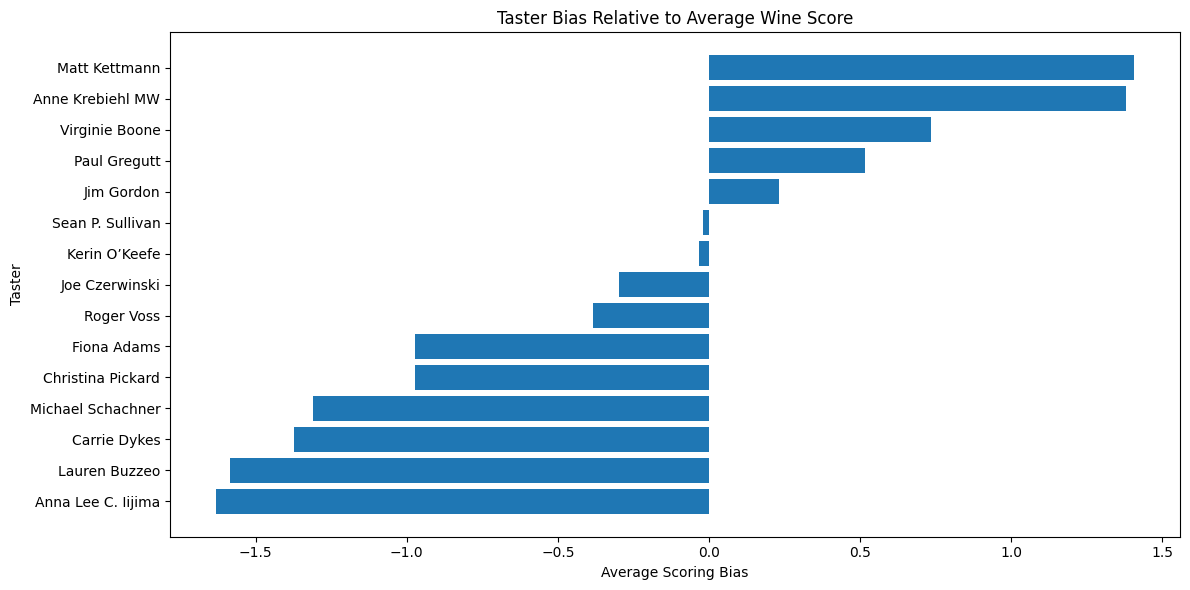

In [ ]:
# @title
plt.figure(figsize=(12,6))

plt.barh(
    top_tasters.get_column("taster_name").to_list()[::-1],
    top_tasters.get_column("bias").to_list()[::-1]
)

plt.xlabel("Average Scoring Bias")
plt.ylabel("Taster")
plt.title("Taster Bias Relative to Average Wine Score")

plt.tight_layout()
plt.show()

##**Introduction**


We chose to analyze the wine tasting dataset because the wine market presents a useful data science problem: prices and ratings often feel opaque and unintuitive, even to experienced consumers. Wines vary across region, flavor profile, price, and expert score, but the relationships among these variables are not always clear. This makes the dataset well suited for exploring how measurable wine attributes relate to perceived quality and market value.
The wine market presents an interesting data science problem because price and expert scores are often treated as signals of quality, yet many consumers find these signals difficult to interpret. Wines vary widely across region, flavor profile, price, and expert rating, but the relationships among these factors are not always clear. As a result, consumers frequently rely on simplified indicators such as price or score when selecting wines, even though these indicators may not reflect the objective value of the wine.

In this project, we examine how wine scores and prices are shaped by three key influences: descriptive flavor language, regional reputation, and reviewer behavior. Rather than assuming that ratings and prices directly reflect objective quality, we investigate whether these outcomes are partially driven by patterns in how wines are described, where they are produced, and who evaluates them.

By analyzing these factors together, we aim to better understand why wine prices and scores can appear opaque to consumers. The wine dataset provides a useful opportunity to study how subjective signals (such as descriptive language, regional identity, and reviewer interpretation) interact to shape perceived value in a consumer market. Through this analysis, we seek to provide insights that may help both consumers and retailers interpret wine ratings and pricing more effectively.



##**Background**

This project was partly motivated by Yuri’s interest in the food and beverage industry and his pursuit of an Introductory Sommelier Certification. Through tasting a wide range of wines, he found it surprisingly difficult to consistently distinguish differences in quality, especially between bottles with very different price points. This raised a broader question: if quality differences are difficult to identify even through tasting, why are wine prices and expert scores often treated as reliable indicators of quality?

Prior research suggests this difficulty is common. In a study of online wine auctions, Onur, Bruwer, and Lockshin note that wine is a particularly “challenging” product because buyers are often unable to taste it before purchase. They also explain that “sensory products generally lack product transparency and have hidden information because their attributes are often difficult to express in words.” As a result, consumers frequently rely on expert opinion and signals—such as reputation or provenance—to evaluate quality.

Their study illustrates the economic effects of this uncertainty: in a dataset of 3,535 online wine auctions, wines with verified provenance were 5.7 percentage points more likely to sell and achieved prices about 5.1% higher, resulting in a 7.3% increase in expected seller revenue.

Motivated by these findings, we decided to explore the wine dataset to better understand how wine characteristics, ratings, and other signals relate to price in an opaque market.


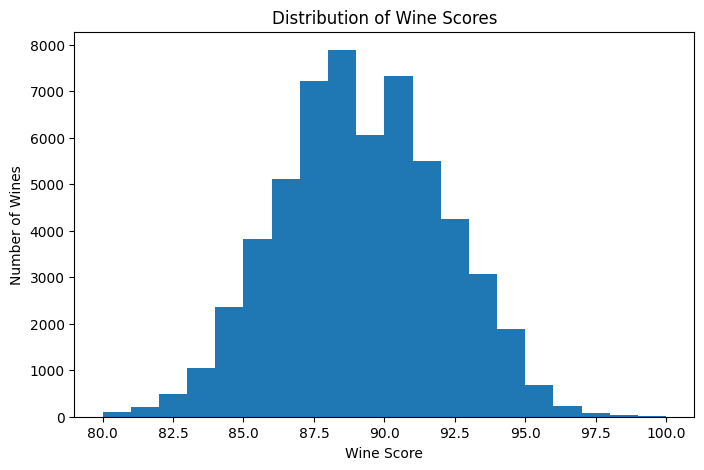

In [ ]:
# @title
score_values = (
    df
    .drop_nulls(["points"])
    .get_column("points")
    .to_list()
)

plt.figure(figsize=(8,5))
plt.hist(score_values, bins=20)

plt.xlabel("Wine Score")
plt.ylabel("Number of Wines")
plt.title("Distribution of Wine Scores")
plt.show()
top_regions = region_summary.head(15)




##**Substantiation**

##Q1) Keywine flavors



We scanned the whole text in the wine descriptions column and counted how often two word flavor phrases appeared, while ignoring very common filler words. We removed grape variety phrases so the final list focused on flavor descriptions. A new column `flavor_tags` is created to list the flavor descriptors present in each wine.

In [ ]:
# @title
# Reuse cleaned data from earlier sections and keep rows needed for Q1
df_q1 = df.drop_nulls(subset=["clean_desc", "price", "points"])

# Top 12 bigrams from cleaned descriptions
vectorizer = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=20)
X = vectorizer.fit_transform(df_q1["clean_desc"].to_list())
phrases = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

top_12 = [
    p for p, _ in sorted(zip(phrases, counts),
                         key=lambda x: x[1],
                         reverse=True)[:12]
]

# Remove grape variety phrases and keep top 10 flavor descriptors
excluded = {"pinot noir", "cabernet sauvignon"}
top_phrases = [p for p in top_12 if p not in excluded][:10]

print("Top 12 phrases before filtering:")
print("\n".join(top_12))
print("\nTop 10 flavor phrases:")
print("\n".join(top_phrases))

# Tag wines with the selected phrases
patterns = {p: re.compile(rf"\b{re.escape(p)}\b") for p in top_phrases}
df_q1 = df_q1.with_columns(
    pl.col("clean_desc").map_elements(
        lambda t: [p for p, r in patterns.items() if r.search(t)]
    ).alias("flavor_tags")
)

Top 12 phrases before filtering:
black cherry
fruit flavors
palate offers
cabernet sauvignon
medium bodied
ready drink
black fruit
black pepper
red berry
drink 2018
red fruit
cabernet franc

Top 10 flavor phrases:
black cherry
fruit flavors
palate offers
medium bodied
ready drink
black fruit
black pepper
red berry
drink 2018
red fruit


The highest-frequency flavor-oriented phrases were:

In [ ]:
top_phrases = [
    "black cherry", "fruit flavors", "palate offers", "ready drink",
    "medium bodied", "black fruit", "black pepper",
    "red berry", "black currant", "red fruit"
]


The phrase frequency analysis shows that flavor language is concentrated around a small set of recurring descriptors.

In [ ]:
# @title
# Build case-insensitive regex from selected phrases
pattern = "(?i)(" + "|".join(map(re.escape, top_phrases)) + ")"

# Tag + explode
df_exp = (
    df_q1.with_columns(
        pl.col("clean_desc").str.extract_all(pattern).alias("flavor_tags")
    )
    .explode("flavor_tags")
    .drop_nulls("flavor_tags")
    .with_columns(pl.col("flavor_tags").str.to_lowercase())
)

result = (
        df_exp
        .group_by("flavor_tags")
        .agg([
            pl.len().alias("num_wines"),
            pl.col("points").mean().alias("avg_points"),
            pl.col("points").std().alias("std_points"),
            pl.col("price").mean().alias("avg_price"),
        ])
        .sort("avg_points", descending=True)
    )

print("\nFlavor Profile Statistics:")
print(result)


Flavor Profile Statistics:
shape: (10, 5)
┌───────────────┬───────────┬────────────┬────────────┬───────────┐
│ flavor_tags   ┆ num_wines ┆ avg_points ┆ std_points ┆ avg_price │
│ ---           ┆ ---       ┆ ---        ┆ ---        ┆ ---       │
│ str           ┆ u32       ┆ f64        ┆ f64        ┆ f64       │
╞═══════════════╪═══════════╪════════════╪════════════╪═══════════╡
│ black pepper  ┆ 1471      ┆ 89.923861  ┆ 2.544231   ┆ 47.308634 │
│ black cherry  ┆ 3957      ┆ 89.729593  ┆ 2.580291   ┆ 45.72277  │
│ black fruit   ┆ 1889      ┆ 89.625728  ┆ 2.842846   ┆ 47.646903 │
│ black currant ┆ 999       ┆ 89.048048  ┆ 2.803107   ┆ 44.890891 │
│ ready drink   ┆ 42        ┆ 89.047619  ┆ 2.946286   ┆ 39.428571 │
│ fruit flavors ┆ 3676      ┆ 88.592492  ┆ 2.650198   ┆ 31.635745 │
│ palate offers ┆ 2538      ┆ 88.509456  ┆ 2.221857   ┆ 38.912136 │
│ red berry     ┆ 1085      ┆ 88.467281  ┆ 2.728503   ┆ 39.090323 │
│ red fruit     ┆ 1984      ┆ 88.453629  ┆ 2.934976   ┆ 38.890625 │
│ med

Flavor notes like black pepper, black cherry, and black fruit are also associated with relatively high ratings (around 89.6–90) and mid-to-high price ranges. In contrast, broader descriptors such as fruit flavors, red berry, red fruit, and medium bodied tend to have slightly lower ratings and lower average prices, indicating they may correspond to more common or moderately priced wines.

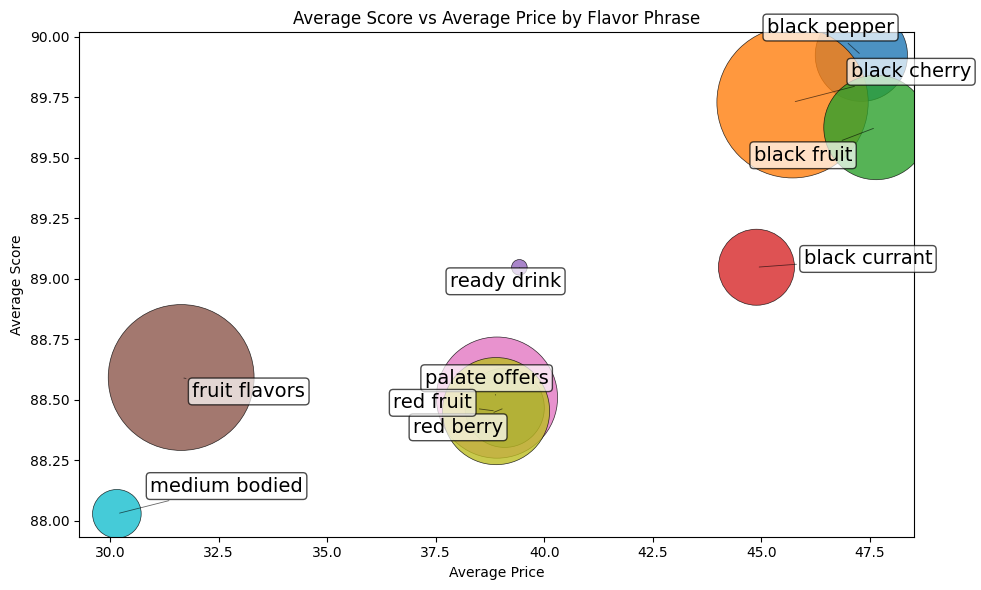

In [ ]:
# @title
# Scatter plot of average score vs average price by flavor phrase
plot_df = result.sort("avg_points", descending=True)

x = plot_df.get_column("avg_price").to_list()
y = plot_df.get_column("avg_points").to_list()
sizes = [n * 3 for n in plot_df.get_column("num_wines").to_list()]
labels = plot_df.get_column("flavor_tags").to_list()

# Assign a different color to each point
colors = plt.cm.tab10(range(len(labels)))

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=sizes, c=colors, alpha=0.8, edgecolors="black", linewidths=0.5)

# Custom offset for each flavor label
custom_offsets = {
    "black cherry": (42, 18),
    "fruit flavors": (8, -14),
    "palate offers": (-52, 10),
    "ready drink": (-50, -14),
    "medium bodied": (24, 16),
    "black fruit": (-88, -24),
    "black pepper": (-68, 16),
    "red berry": (-66, -18),
    "black currant": (34, 2),
    "red fruit": (-74, 2),
}

for i, label in enumerate(labels):
    dx, dy = custom_offsets.get(label, (10, 10))
    plt.annotate(
        label,
        (x[i], y[i]),
        fontsize=14,
        xytext=(dx, dy),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6)
    )

plt.xlabel("Average Price")
plt.ylabel("Average Score")
plt.title("Average Score vs Average Price by Flavor Phrase")
plt.tight_layout()
plt.show()

##Q2) What provinces/region produces the highest scoring wines? How does region affect flavor profiles and scores

To understand how geographic origin influences wine quality and flavor characteristics, we analyzed the relationship between wine regions, flavor descriptors. Here we calculate the total number and percentage of wine reviews per country and then visualize it.

In [ ]:
# @title
import polars as pl
import plotly.express as px

# Clean country names for mapping
df_clean = (
    df
    .drop_nulls(["country"])
    .with_columns(
        pl.when(pl.col("country") == "US").then(pl.lit("United States"))
        .when(pl.col("country") == "England").then(pl.lit("United Kingdom"))
        .otherwise(pl.col("country"))
        .alias("country")
    )
)

# Total number of reviews
total_reviews = df_clean.height

# Count reviews per country
country_counts = (
    df_clean
    .group_by("country")
    .agg(pl.len().alias("review_count"))
)

# Calculate percentage share
country_percentage = (
    country_counts
    .with_columns(
        ((pl.col("review_count") / total_reviews) * 100)
        .round(2)
        .alias("percent_reviews")
    )
    .sort("percent_reviews", descending=True)
)

country_percentage_pd = country_percentage.to_pandas()

fig = px.choropleth(
    country_percentage_pd,
    locations="country",
    locationmode="country names",
    color="percent_reviews",
    hover_name="country",
    color_continuous_scale="Plasma",
    title="Percentage of Wine Reviews by Country"

)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

In [ ]:
# @title
import plotly.express as px

# Top 10 countries by average wine rating
avg_rating_map_df = (
    df
    .drop_nulls(["country", "points"])
    .with_columns(
        pl.when(pl.col("country") == "US").then(pl.lit("United States"))
        .when(pl.col("country") == "England").then(pl.lit("United Kingdom"))
        .otherwise(pl.col("country"))
        .alias("country")
    )
    .group_by("country")
    .agg([
        pl.col("points").mean().round(2).alias("avg_rating"),
        pl.len().alias("review_count")
    ])
    .sort("avg_rating", descending=True)
    .head(10)
)

avg_rating_map_pd = avg_rating_map_df.to_pandas()

fig = px.choropleth(
    avg_rating_map_pd,
    locations="country",
    locationmode="country names",
    color="avg_rating",
    hover_name="country",
    hover_data={"avg_rating": True, "review_count": True},
    color_continuous_scale="Plasma",
    title="Top Countries by Average Wine Rating"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar_title="Avg rating"
)

fig.show()

Here, we group wines by region and calcualte their average scores.

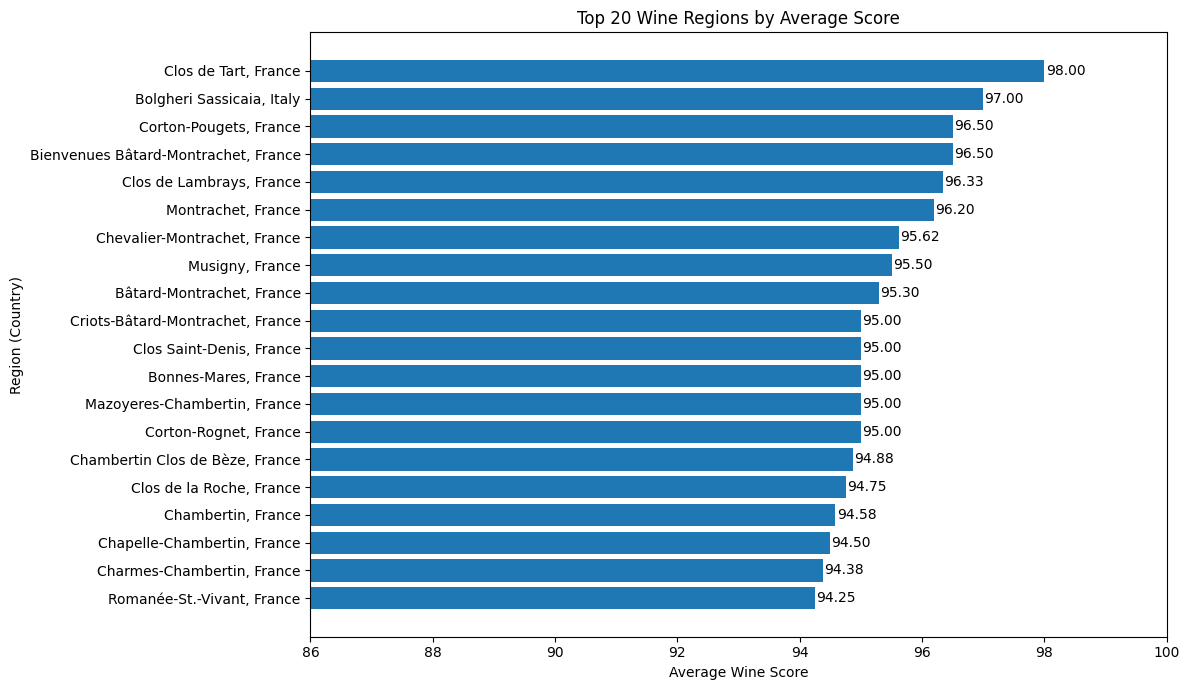

In [ ]:
# @title
region_avg = (
    df.group_by("country", "region")
      .agg(pl.col("points").mean().alias("avg_points"))
      .sort("avg_points", descending=True)
)

region_avg.head(20)

top_regions = region_avg.head(20)

regions = top_regions.get_column("region").to_list()
countries = top_regions.get_column("country").to_list()
scores = top_regions.get_column("avg_points").to_list()

labels = [f"{r}, {c}" for r, c in zip(regions, countries)]

plt.figure(figsize=(12,7))

plt.barh(labels[::-1], scores[::-1])

for i, v in enumerate(scores[::-1]):
    plt.text(v + 0.02, i, f"{v:.2f}", va='center')

plt.xlabel("Average Wine Score")
plt.ylabel("Region (Country)")
plt.title("Top 20 Wine Regions by Average Score")

plt.xlim(86,100)

plt.tight_layout()
plt.show()

The results show that the highest-scoring wines often come from very specific wine regions rather than broad geographic areas. Regions such as Bolgheri Sassicaia in Italy, Corton-Pougets, Bienvenues Bâtard-Montrachet, Clos de Lambrays, and Musigny in France appear among the highest scoring regions in the dataset based on their average wine scores. Many of these regions are well-known appellations associated with high-quality wine production, particularly within the Burgundy region of France. This suggests that historically prestigious vineyard areas continue to perform strongly in expert evaluations. The dataset would be cleaned to make sure that each review has at least more than one instance to prevent a bias review.

However, we will later see instances of bias influence these scores.

##Q3) Does the wine taster have an affect on the overall score given the wine/region?



Because wine scores may vary depending on the reviewer, we also adjusted the scores to account for reviewer bias. This was done by calculating each reviewer's average score and comparing it to the global average score across the dataset. The difference between these values was treated as the reviewer's bias. We then created an adjusted score by subtracting the reviewer bias from each individual rating. This adjustment helps ensure that differences between regions are not simply the result of certain reviewers consistently scoring higher or lower than others.



In [ ]:
# @title
top10_titles = (
    df
    .group_by("title")
    .agg(
        pl.col("points").mean().alias("avg_points"),
        pl.col("price").mean().alias("avg_price"),
        pl.len().alias("n_reviews")
    )
    .filter(pl.col("n_reviews") > 2)
    .with_columns(
        pl.col("avg_points")
        .rank(method="dense", descending=True)
        .alias("rank")
    )
    .filter(pl.col("rank") <= 10)
    .sort("rank")
)

top10_titles

title,avg_points,avg_price,n_reviews,rank
str,f64,f64,u32,u32
"""Taittinger NV Prélude Grands C…",92.666667,88.333333,3,1
"""Billecart-Salmon NV Brut Rosé …",92.0,80.0,3,2
"""Billecart-Salmon NV Grand Cru …",91.333333,78.333333,3,3
"""Château Malartic-Lagravière 20…",91.333333,55.0,3,3
"""Château la Garde 2012 Pessac-…",91.333333,45.0,3,3
…,…,…,…,…
"""Domaine Delaporte 2014 Sancer…",90.333333,null,3,8
"""Boizel NV Ultime Extra Brut (…",90.0,70.333333,3,9
"""Henri Abele NV Brut (Champagn…",90.0,33.666667,3,9


In [ ]:
# @title
df = (
    pl.read_csv("winemag-data-130k-v2.csv")
    .with_columns([
        pl.col("region_2").str.strip_chars().replace("", None),
    ])
    .with_columns(
        pl.coalesce([pl.col("region_1"), pl.col("region_2")]).alias("region")
    )
    .drop(["region_1", "region_2", "designation"])
    .drop_nulls(["region", "taster_name"])
)

wine_baseline = (
    df.group_by("title")
      .agg([
          pl.col("points").mean().alias("wine_avg_points"),
          pl.col("taster_name").n_unique().alias("n_tasters"),
          pl.len().alias("n_reviews"),
      ])
      # keep only wines with multiple tasters and enough data
      .filter(
          (pl.col("n_tasters") >= 2) &
          (pl.col("n_reviews") > 2)
      )
)

df_residuals = (
    df.join(
        wine_baseline.select(["title", "wine_avg_points"]),
        on="title",
        how="inner"
    )
    .with_columns(
        (pl.col("points") - pl.col("wine_avg_points")).alias("residual")
    )
)
taster_region_bias = (
    df_residuals.group_by(["taster_name", "region"])
        .agg([
            pl.len().alias("n_reviews"),
            pl.col("residual").mean().alias("mean_bias"),
        ])
        .filter(pl.col("n_reviews") > 2)
        .sort(["taster_name", "mean_bias"], descending=[False, True])
)
print(taster_region_bias)

shape: (4, 4)
┌──────────────────┬──────────────────┬───────────┬───────────┐
│ taster_name      ┆ region           ┆ n_reviews ┆ mean_bias │
│ ---              ┆ ---              ┆ ---       ┆ ---       │
│ str              ┆ str              ┆ u32       ┆ f64       │
╞══════════════════╪══════════════════╪═══════════╪═══════════╡
│ Anne Krebiehl MW ┆ Crémant d'Alsace ┆ 10        ┆ 1.116667  │
│ Jim Gordon       ┆ North Coast      ┆ 3         ┆ 0.583333  │
│ Roger Voss       ┆ Champagne        ┆ 11        ┆ -0.330303 │
│ Roger Voss       ┆ Crémant d'Alsace ┆ 8         ┆ -1.114583 │
└──────────────────┴──────────────────┴───────────┴───────────┘


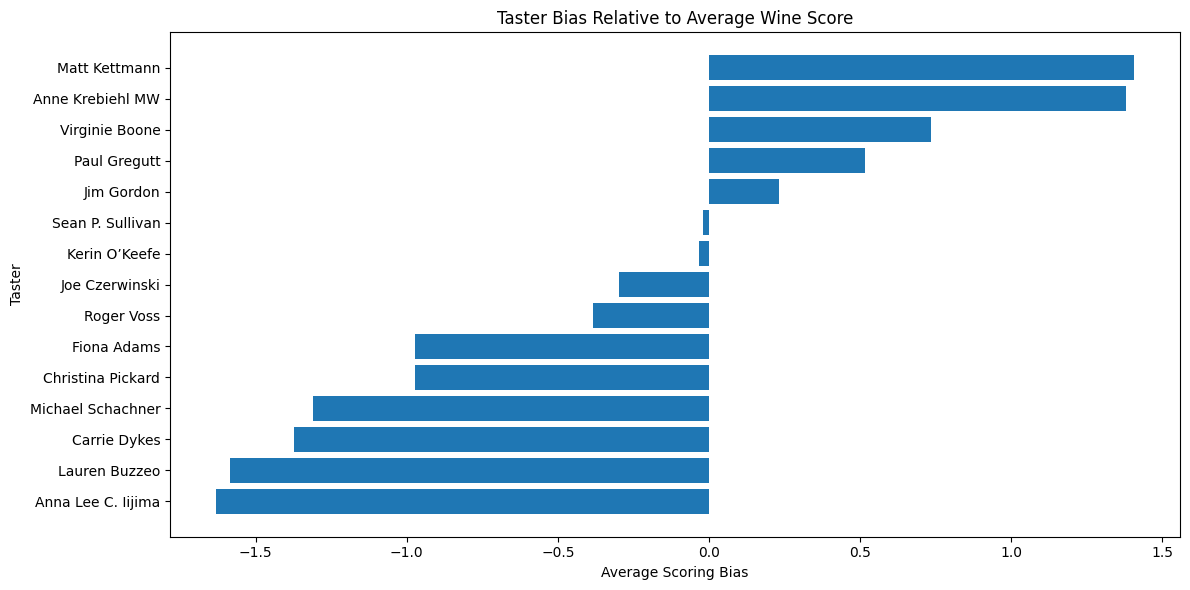

In [ ]:
# @title
plt.figure(figsize=(12,6))

plt.barh(
    top_tasters.get_column("taster_name").to_list()[::-1],
    top_tasters.get_column("bias").to_list()[::-1]
)

plt.xlabel("Average Scoring Bias")
plt.ylabel("Taster")
plt.title("Taster Bias Relative to Average Wine Score")

plt.tight_layout()
plt.show()

###


The taster bias analysis shows clear differences in how individual reviewers score wines relative to the overall dataset average. For example, reviewers such as Matt Kettmann and Anne Krebiehl MW exhibit positive scoring biases of roughly +1.3 to +1.5 points, meaning that on average they rate wines about one to one-and-a-half points higher than the typical score across the dataset. This suggests they may be relatively generous evaluators. In contrast, reviewers such as Anna Lee C. Iijima and Lauren Buzzeo show negative biases approaching −1.5 points, indicating they tend to score wines more strictly than the overall average. Although a difference of one to two points may appear small on a 100-point wine rating scale, it can meaningfully influence how wines are perceived, especially when consumers or retailers compare wines with very similar scores. These findings highlight the importance of adjusting for reviewer bias when analyzing wine ratings, as failing to account for these systematic differences could lead to misleading conclusions about the quality of wines from particular regions or flavor profiles.




## Conclusion

Overall, our analysis shows that for consumers mean price should not be treated as a perfect indicator of quality. For retailers, the results suggest that stocking and marketing wines around popular regional identities and recognizable flavor profiles may be more useful than relying on price alone.